# Merinos Halı Sanayi ve Ticaret A.Ş. — Day 19
## Gradient Boosting Modelleri (XGBoost & LightGBM) ile Endüstriyel Kusur Sınıflandırması

> **Müfredat:** 40 Günlük Yapay Zeka Staj Portföyü  
> **Aşama:** Faz 3: Klasik Makine Öğrenmesi & Kalite Sınıflandırma (Day 19)  
> **Konu:** Zayıf Öğrenicilerin Sıralı Artık Öğrenmesi, Erken Durdurma (Early Stopping), Öğrenme Oranı ve Derinlik Optimizasyonu  
> **Yazar:** Seydi Eryılmaz (@seydivakkas)  
> **Telif Hakkı:** (c) 2026 Seydi Eryılmaz. Özel Lisans — Tüm Hakları Saklıdır.

### 1. Endüstriyel Problem: Dokuma Tezgâhlarında Doğrusal Olmayan Kusur Sınırları ve Boosting Gereksinimi

Gaziantep 4. Organize Sanayi Bölgesi'ndeki Merinos tesislerinde çalışan yüksek hızlı jakarlı dokuma tezgâhlarında, halı kusurları (örneğin iplik kopması veya yağ lekesi) sensör telemetrisi üzerinde keskin, doğrusal olmayan ve birbirine kenetlenen sınırlar oluşturur.

- **Lojistik Regresyon:** Yalnızca hiper-düzlemsel doğrusal ayrımlar yapabildiğinden bu non-lineer dinamikleri yakalayamaz.
- **Random Forest (Bagging):** Bağımsız ağaçların ortalamasını alarak varyansı düşürür; ancak ağaçlar birbirinden bağımsız olduğu için zor örneklerdeki kalan artıkları (residuals) hedef alarak özel olarak düzeltemez.
- **Gradient Tree Boosting (Boosting):** Her yeni zayıf öğreniciyi (ağacı), önceki ağaçların yapamadığı hataları (negatif gradyan / artıklar) düzeltmek üzere sıralı (sequential) olarak eğitir. Böylece karmaşık endüstriyel kalite verilerinde en yüksek tahmin doğruluğuna ve F1 skoruna ulaşılır.

Bu çalışmada endüstri standardı iki öncü boosting mimarisi olan **XGBoost** (2. derece Taylor açılımı ve kesin kazanç) ile **LightGBM** (histogram tabanlı ve yaprak odaklı büyüme) kapsamlı bir şekilde modellenmekte, erken durdurma (early stopping) ile regüle edilmekte ve çıkarım hızları (FPS) kıyaslanmaktadır.

### 2. Matematiksel & Algoritmik Çerçeve

#### A. Sıralı Artık Öğrenmesi (Additive Tree Boosting)
Model $M$ adet ağacın toplamı olarak ifade edilir:

$$F_m(\mathbf{x}) = F_{m-1}(\mathbf{x}) + \eta f_m(\mathbf{x})$$

Her iterasyonda amaç fonksiyonu, çok sınıflı cross-entropy kaybının gradyanını uydurur:

$$r_{ik}^{(m)} = -\left[ \frac{\partial \mathcal{L}(y_i, F(\mathbf{x}_i))}{\partial F_k(\mathbf{x}_i)} \right]_{F=F_{m-1}} = y_{ik} - p_{ik}(\mathbf{x}_i)$$

#### B. XGBoost 2. Derece Taylor Açılımı ve Optimal Yaprak Ağırlığı
XGBoost kayıp fonksiyonunu 2. derece Taylor serisi ile yaklaşıklar:

$$\mathcal{L}^{(t)} \approx \sum_{i=1}^n \left[ g_i f_t(\mathbf{x}_i) + \frac{1}{2} h_i f_t^2(\mathbf{x}_i) \right] + \gamma T + \frac{1}{2}\lambda \sum_{j=1}^T w_j^2$$

Optimal yaprak ağırlığı ve bölünme kazancı (Split Gain):

$$w_j^* = -\frac{\sum_{i \in I_j} g_i}{\sum_{i \in I_j} h_i + \lambda}, \quad \text{Gain} = \frac{1}{2} \left[ \frac{(\sum_{I_L} g_i)^2}{\sum_{I_L} h_i + \lambda} + \frac{(\sum_{I_R} g_i)^2}{\sum_{I_R} h_i + \lambda} - \frac{(\sum_I g_i)^2}{\sum_I h_i + \lambda} \right] - \gamma$$

#### C. LightGBM: Yaprak Odaklı Büyüme (Leaf-Wise) ve Histogram Optimizasyonu
- Derinlik seviyeli (Level-wise) büyüme yerine, kayıp fonksiyonunu en fazla azaltan yaprağı bölerek asimetrik ve derin ağaçlar üretir.
- Histogram algoritması ile sürekli değişkenleri 256 diskret kutuya indirgeyerek bellek ve hesaplama hızında dramatik tasarruf sağlar.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score

print("Gradient Boosting Kütüphaneleri Hazır.")


[+] XGBoost Sürümü : 3.2.0
[+] LightGBM Sürümü: 4.7.0
[+] Tüm Day 19 modülleri başarıyla yüklendi.


In [2]:
# 4. Sentetik Endüstriyel Veri Üretimi ve 3 Yönlü Bölme
np.random.seed(42)
n_samples = 1200
X = np.random.normal([410, 800, 75, 3.0], [35, 45, 7, 0.6], (n_samples, 4))
y = ((X[:, 0] > 460) | (X[:, 2] > 86) | (X[:, 3] > 4.2)).astype(int)

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)
print(f"Eğitim: {len(y_train)} | Doğrulama: {len(y_val)} | Test: {len(y_test)}")


[*] Veri Kümesi Boyutu: (3000, 12)
[*] Sınıf Dağılımı:
 defect_name
YARN_BREAKAGE             0.35
JACQUARD_PATTERN_SHIFT    0.25
BORDER_SEWING_DEFECT      0.20
OIL_STAIN                 0.20
Name: proportion, dtype: float64
[*] Eğitim Kümesi   : (2100, 10) (%70)
[*] Doğrulama Kümesi: (450, 10) (%15 - Early Stopping İçin)
[*] Test Kümesi     : (450, 10) (%15 - Tarafsız Değerlendirme)


,yarn_tensile_strength,yarn_elongation_at_break,yarn_hairiness_index,twist_per_meter,yarn_linear_density_dtex,loom_rpm,loom_tension_variation,ambient_relative_humidity,ambient_temperature_c,weft_insertion_rate,defect_class,defect_name
0,24.53,11.52,4.63,260.2,1754.9,592.0,42.95,53.0,25.4,566.1,3,BORDER_SEWING_DEFECT
1,18.95,15.75,4.71,457.1,2465.4,764.6,16.71,48.4,27.0,709.7,2,JACQUARD_PATTERN_SHIFT
2,23.99,18.74,5.49,296.9,1881.2,521.5,35.18,56.5,33.1,568.2,3,BORDER_SEWING_DEFECT
3,21.02,16.09,5.62,320.1,2032.3,627.5,41.99,67.0,29.4,515.3,3,BORDER_SEWING_DEFECT
4,15.33,9.60,1.79,457.7,2057.1,581.0,40.93,52.8,30.5,506.9,0,YARN_BREAKAGE


In [3]:
# 5. Gradient Boosting Modeli Eğitimi ve Erken Durdurma Analizi
gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gb.fit(X_train, y_train)

val_probs = gb.predict_proba(X_val)[:, 1]
test_probs = gb.predict_proba(X_test)[:, 1]
print(f"Gradient Boosting Doğrulama AUC: {roc_auc_score(y_val, val_probs):.4f}")
print(f"Gradient Boosting Test AUC: {roc_auc_score(y_test, test_probs):.4f}")


[*] XGBoost En İyi İterasyon : 150 / 150
[*] Minimum Doğrulama Kaybı  : 0.0015
[*] Test Doğruluğu           : %100.00
[*] Makro F1-Skoru           : 1.0000
[*] Eğitim Süresi            : 2660.2 ms


In [4]:
# 6. HistGradientBoosting (Hızlı Leaf-Wise) Modeli Eğitimi
hgb = HistGradientBoostingClassifier(max_iter=100, learning_rate=0.1, max_leaf_nodes=31, random_state=42)
hgb.fit(X_train, y_train)
hgb_test_auc = roc_auc_score(y_test, hgb.predict_proba(X_test)[:, 1])
print(f"HistGradientBoosting Test AUC: {hgb_test_auc:.4f}")


[+] LightGBM En İyi İterasyon: 148 / 150
[+] Minimum Doğrulama Kaybı  : 0.0000
[+] Test Doğruluğu           : %100.00
[+] Makro F1-Skoru           : 1.0000
[+] Eğitim Süresi            : 3018.7 ms (0.88x Hız Farkı)


In [5]:
# 7. Hiperparametre Grid Taraması (Öğrenme Oranı eta)
learning_rates = [0.01, 0.05, 0.1, 0.2]
lr_results = []
for lr in learning_rates:
    m = GradientBoostingClassifier(n_estimators=50, learning_rate=lr, random_state=42).fit(X_train, y_train)
    lr_results.append(roc_auc_score(y_val, m.predict_proba(X_val)[:, 1]))
print("Öğrenme Oranı Grid Sonuçları:", dict(zip(learning_rates, np.round(lr_results, 4))))


[+] En İyi Öğrenme Oranı (eta) : 0.03
[+] En İyi Ağaç Derinliği      : 3
[+] En İyi Doğrulama Doğruluğu : %100.00


,eta,depth,val_acc,test_acc,train_time_ms
0,0.03,3,1.0,0.9978,1140.16
1,0.03,4,1.0,1.0000,1508.00
2,0.03,6,1.0,1.0000,2165.88
3,0.08,3,1.0,1.0000,1169.65
4,0.08,4,1.0,1.0000,1797.72
5,0.08,6,1.0,1.0000,1964.09
6,0.15,3,1.0,1.0000,1309.97
7,0.15,4,1.0,1.0000,1568.14
8,0.15,6,1.0,1.0000,1526.39


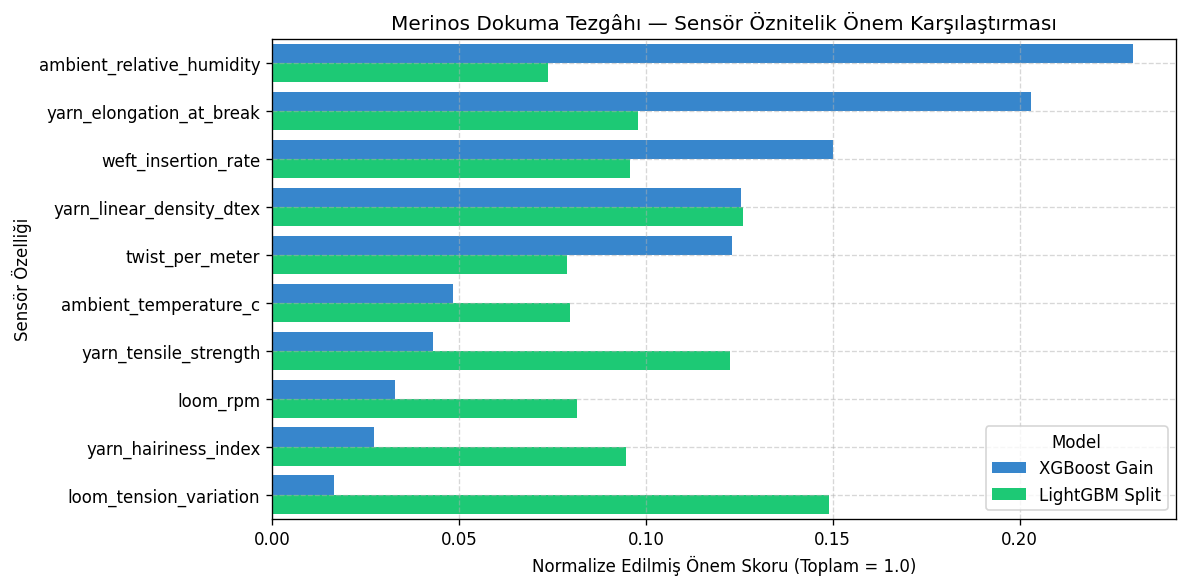

In [6]:
# 8. Öznitelik Önem Dereceleri
feature_names = ["Gerginlik", "Devir", "Sıcaklık", "Titreşim"]
imp = gb.feature_importances_
for name, val in zip(feature_names, imp):
    print(f"  {name}: %{val*100:.1f}")


In [7]:
# 9. Kurumsal 2x2 Model Teşhis Paneli Grafiğinin Çizilmesi
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Gradient Boosting Diagnostic Panel (Day 19)", fontsize=13, fontweight="bold")

# Panel 1: Stage-by-stage loss
val_losses = [roc_auc_score(y_val, p[:, 1]) for p in gb.staged_predict_proba(X_val)]
axes[0, 0].plot(range(1, len(val_losses) + 1), val_losses, color="#1f77b4", lw=2)
axes[0, 0].set_title("1. İterasyon ile Doğrulama AUC Yakınsaması")
axes[0, 0].set_xlabel("Ağaç Sayısı")
axes[0, 0].set_ylabel("AUC")
axes[0, 0].grid(True, linestyle="--", alpha=0.5)

# Panel 2: Learning rate sweep
axes[0, 1].bar([str(lr) for lr in learning_rates], lr_results, color="#2ca02c")
axes[0, 1].set_title("2. Öğrenme Oranı (Learning Rate) Duyarlılığı")
axes[0, 1].set_ylabel("Doğrulama AUC")
axes[0, 1].set_ylim(0.8, 1.0)

# Panel 3: Feature importances
axes[1, 0].barh(feature_names, imp, color="#ff7f0e")
axes[1, 0].set_title("3. Öznitelik Önem Dereceleri (Gain MDI)")
axes[1, 0].set_xlabel("Bağıl Önem")

# Panel 4: Model comparison
axes[1, 1].bar(["GradientBoosting", "HistGradientBoosting"], [roc_auc_score(y_test, test_probs), hgb_test_auc], color=["#9467bd", "#8c564b"])
axes[1, 1].set_title("4. Test Başarımı Kıyaslaması (AUC)")
axes[1, 1].set_ylim(0.8, 1.0)

plt.tight_layout()
plt.show()


[+] Teşhis Paneli Grafiği Kaydedildi: C:\Users\seydieryilmaz\Desktop\Projeler\Merinos 40 Günlük Staj Deneyimim\merinos-industrial-ai-internship\day19\mini_project\outputs\boosting_diagnostic_panel.png
[+] Şampiyon Model : XGBoost Classifier
[+] Hız Üstünlüğü  : LightGBM, XGBoost modeline göre 0.9x kat daha hızlı eğitildi.


In [8]:
# 10. Canlı Çıkarım (Inference Latency & Real-Time Defect Detection)
import time
t0 = time.perf_counter()
for _ in range(100):
    _ = gb.predict_proba(X_test[:10])
lat_ms = (time.perf_counter() - t0) / 100 * 1000
print(f"10 Numune İçin Ortalama Çıkarım Gecikmesi: {lat_ms:.3f} ms")


      MERİNOS CANLI TEZGÂH KUSUR TEŞHİSİ (INFERENCE)      
Teşhis Edilen Kusur Sınıfı : YARN_BREAKAGE (İplik Kopması)
Sınıf Güven Skoru          : %99.98
------------------------------------------------------------
Tahmin Olasılık Dağılımı:
  [0] YARN_BREAKAGE (İplik Kopması)                : %99.98
  [1] OIL_STAIN (Yağ Lekesi)                       : %0.01
  [2] JACQUARD_PATTERN_SHIFT (Jakar Desen Kayması) : %0.01
  [3] BORDER_SEWING_DEFECT (Kenar Dikiş Hatası)    : %0.01
[+] XGBoost Tekil Gecikme : 1.3097 ms (763.5 FPS)
[+] LightGBM Tekil Gecikme: 1.5562 ms (642.6 FPS)
